# Ex. Monte Carlo Uncertainty Quantification for Hydrologyic Properties Estimation

This notebook demonstrates the MC Hydro workflow in PyHydroGeophysX.


In [1]:
"""
Ex. Monte Carlo Uncertainty Quantification for Hydrologyic Properties Estimation
====================================================================

This example demonstrates Monte Carlo uncertainty quantification for 
converting ERT resistivity models to water content estimates.

The analysis includes:
1. Loading inverted resistivity models from time-lapse ERT
2. Defining parameter distributions for different geological layers
3. Monte Carlo sampling of petrophysical parameters
4. Probabilistic water content estimation with uncertainty bounds
5. Statistical analysis and visualization of results
6. Time series extraction with confidence intervals
7. Eastimate the porosity in satuatd zone

Uncertainty quantification is essential for reliable hydrological 
interpretation of geophysical data, providing confidence bounds on
water content estimates and identifying regions of high/low certainty.
"""

'\nEx. Monte Carlo Uncertainty Quantification for Hydrologyic Properties Estimation\n====================================================================\n\nThis example demonstrates Monte Carlo uncertainty quantification for \nconverting ERT resistivity models to water content estimates.\n\nThe analysis includes:\n1. Loading inverted resistivity models from time-lapse ERT\n2. Defining parameter distributions for different geological layers\n3. Monte Carlo sampling of petrophysical parameters\n4. Probabilistic water content estimation with uncertainty bounds\n5. Statistical analysis and visualization of results\n6. Time series extraction with confidence intervals\n7. Eastimate the porosity in satuatd zone\n\nUncertainty quantification is essential for reliable hydrological \ninterpretation of geophysical data, providing confidence bounds on\nwater content estimates and identifying regions of high/low certainty.\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pygimli as pg
import sys
from tqdm import tqdm

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.petrophysics.resistivity_models import resistivity_to_saturation

C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\__init__.py:15: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  import SimPEG as _simpeg


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\meshTools.py:56: UserWarning: pyvista not installed, 3D meshing viewing options will be limited
  warnings.warn('pyvista not installed, 3D meshing viewing options will be limited')


API path =  C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy
ResIPy version =  3.5.4
cR2.exe found and up to date.


R3t.exe found and up to date.
cR3t.exe found and up to date.
[PyHydroGeophysX] RESIPY loaded successfully
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.24.0)


### MC sampling for paramters

In [3]:


# Extract the inverted resistivity values
resistivity_values = np.load("results/Structure_WC/resmodel.npy")
coverage = np.load("results/Structure_WC/all_coverage.npy")
# Extract cell markers from the mesh (to identify different geological layers)
cell_markers = np.load("results/Structure_WC/index_marker.npy")

mesh = pg.load("results/Structure_WC/mesh_res.bms")

# Number of Monte Carlo realizations
n_realizations = 100

# Set up parameter distributions (means and standard deviations)
# Updated to use rock physics parameters instead of saturated resistivity

# Layer 1 (top layer - marker 3) - Regolith/Soil
layer1_dist = {
    'm': {'mean': 1.3, 'std': 0.1},               # Cementation exponent (lower for unconsolidated)
    'n': {'mean': 2.1, 'std': 0.1},               # Saturation exponent
    'sigma_sur': {'mean': 1/200, 'std': 1/200},  # Surface conductivity (S/m)
    'porosity': {'mean': 0.42, 'std': 0.05},      # Porosity
}

# Layer 2 (bottom layer - marker 2) - Fractured/Fresh Bedrock
layer2_dist = {
    'm': {'mean': 1.9, 'std': 0.2},               # Cementation exponent (higher for consolidated)
    'n': {'mean': 1.7, 'std': 0.2},               # Saturation exponent
    'porosity': {'mean': 0.25, 'std': 0.15},      # Porosity (lower in bedrock)
}

# Create arrays to store all MC realization results
water_content_all = np.zeros((n_realizations, *resistivity_values.shape))
Saturation_all = np.zeros((n_realizations, *resistivity_values.shape))

# Create arrays to store the parameters used for each realization
params_used = {
    'layer1': {
        'm': np.zeros(n_realizations),
        'rho_fluid': np.zeros(n_realizations),
        'n': np.zeros(n_realizations),
        'sigma_sur': np.zeros(n_realizations),
        'porosity': np.zeros(n_realizations),
    },
    'layer2': {
        'm': np.zeros(n_realizations),
        'rho_fluid': np.zeros(n_realizations),
        'n': np.zeros(n_realizations),
        'sigma_sur': np.zeros(n_realizations),
        'porosity': np.zeros(n_realizations),
    }
}

# Perform Monte Carlo simulation
print("Starting Monte Carlo simulation...")
for mc_idx in tqdm(range(n_realizations), desc="MC Realizations"):
    
    # Sample parameters for each layer from their distributions
    # Layer 1 (Top layer - Regolith/Soil)
    layer1_params = {
        'm': max(0.0, np.random.normal(layer1_dist['m']['mean'], layer1_dist['m']['std'])),
        'rho_fluid': 20,
        'n': max(0.0, np.random.normal(layer1_dist['n']['mean'], layer1_dist['n']['std'])),
        'sigma_sur': max(0.0, np.random.normal(layer1_dist['sigma_sur']['mean'], layer1_dist['sigma_sur']['std'])),
        'porosity': max(0.0, np.random.normal(layer1_dist['porosity']['mean'], layer1_dist['porosity']['std'])),
    }
    
    # Layer 2 (Bottom layer - Bedrock)
    layer2_params = {
        'm': max(0.0, np.random.normal(layer2_dist['m']['mean'], layer2_dist['m']['std'])),
        'rho_fluid': 20,
        'n': max(0.0, np.random.normal(layer2_dist['n']['mean'], layer2_dist['n']['std'])),
        'sigma_sur': 0.0,  # Minimal surface conductivity in bedrock,
        'porosity': max(0.0, np.random.normal(layer2_dist['porosity']['mean'], layer2_dist['porosity']['std'])),
    }
    

    
    # Save the parameters used for this realization
    params_used['layer1']['m'][mc_idx] = layer1_params['m']
    params_used['layer1']['rho_fluid'][mc_idx] = layer1_params['rho_fluid']
    params_used['layer1']['n'][mc_idx] = layer1_params['n']
    params_used['layer1']['sigma_sur'][mc_idx] = layer1_params['sigma_sur']
    params_used['layer1']['porosity'][mc_idx] = layer1_params['porosity']
    
    params_used['layer2']['m'][mc_idx] = layer2_params['m']
    params_used['layer2']['rho_fluid'][mc_idx] = layer2_params['rho_fluid']
    params_used['layer2']['n'][mc_idx] = layer2_params['n']
    params_used['layer2']['sigma_sur'][mc_idx] = layer2_params['sigma_sur']
    params_used['layer2']['porosity'][mc_idx] = layer2_params['porosity']
    
    # Create arrays to store water content and saturation for this realization
    water_content = np.zeros_like(resistivity_values)
    saturation = np.zeros_like(resistivity_values)

    # Create porosity array for all cells
    porosity = np.zeros_like(cell_markers, dtype=float)
    porosity[cell_markers == 3] = layer1_params['porosity'] # Top layer porosity
    porosity[cell_markers == 2] = layer2_params['porosity']  # Bottom layer porosity

    # Process each timestep
    for t in range(resistivity_values.shape[1]):
        # Extract resistivity for this timestep
        resistivity_t = resistivity_values[:, t]
        
        # Process each layer separately using the NEW resistivity_to_saturation function
        
        # Layer 1 (marker 3) - Top layer
        mask_layer1 = cell_markers == 3
        if np.any(mask_layer1):
            saturation[mask_layer1, t] = resistivity_to_saturation(
                resistivity=resistivity_t[mask_layer1],
                porosity=layer1_params['porosity'],
                m=layer1_params['m'],
                rho_fluid=layer1_params['rho_fluid'],
                n=layer1_params['n'],
                sigma_sur=layer1_params['sigma_sur'],
            )
        
        # Layer 2 (marker 2) - Bottom layer
        mask_layer2 = cell_markers == 2
        if np.any(mask_layer2):
            saturation[mask_layer2, t] = resistivity_to_saturation(
                resistivity=resistivity_t[mask_layer2],
                porosity=layer2_params['porosity'],
                m=layer2_params['m'],
                rho_fluid=layer2_params['rho_fluid'],
                n=layer2_params['n'],
                sigma_sur=layer2_params['sigma_sur'],
            )
        
        # Convert saturation to water content (water_content = saturation * porosity)
        water_content[:, t] = saturation[:, t] * porosity
    
    # Store this realization's water content and saturation
    water_content_all[mc_idx] = water_content
    Saturation_all[mc_idx] = saturation

print("Monte Carlo simulation completed!")

# Calculate statistics across all realizations
print("Calculating statistics...")
water_content_mean = np.mean(water_content_all, axis=0)
water_content_std = np.std(water_content_all, axis=0)
water_content_p10 = np.percentile(water_content_all, 10, axis=0)  # 10th percentile
water_content_p50 = np.percentile(water_content_all, 50, axis=0)  # Median
water_content_p90 = np.percentile(water_content_all, 90, axis=0)  # 90th percentile

print("Statistics calculation completed!")

# Print some summary statistics
print(f"\nSummary Statistics:")
print(f"Layer 1 (Regolith) - Mean porosity: {np.mean(params_used['layer1']['porosity']):.3f} ± {np.std(params_used['layer1']['porosity']):.3f}")
print(f"Layer 1 - Mean m: {np.mean(params_used['layer1']['m']):.3f} ± {np.std(params_used['layer1']['m']):.3f}")
print(f"Layer 1 - Mean rho_fluid: {np.mean(params_used['layer1']['rho_fluid']):.1f} ± {np.std(params_used['layer1']['rho_fluid']):.1f} Ω·m")

print(f"\nLayer 2 (Bedrock) - Mean porosity: {np.mean(params_used['layer2']['porosity']):.3f} ± {np.std(params_used['layer2']['porosity']):.3f}")
print(f"Layer 2 - Mean m: {np.mean(params_used['layer2']['m']):.3f} ± {np.std(params_used['layer2']['m']):.3f}")
print(f"Layer 2 - Mean rho_fluid: {np.mean(params_used['layer2']['rho_fluid']):.1f} ± {np.std(params_used['layer2']['rho_fluid']):.1f} Ω·m")

print(f"\nWater content range: {np.min(water_content_mean):.4f} - {np.max(water_content_mean):.4f}")
print(f"Mean uncertainty (std): {np.mean(water_content_std):.4f}")

Starting Monte Carlo simulation...


MC Realizations:   0%|          | 0/100 [00:00<?, ?it/s]

MC Realizations:   1%|          | 1/100 [00:00<00:39,  2.51it/s]

MC Realizations:   3%|▎         | 3/100 [00:00<00:22,  4.38it/s]

MC Realizations:   4%|▍         | 4/100 [00:01<00:26,  3.65it/s]

...

MC Realizations:  98%|█████████▊| 98/100 [00:28<00:00,  3.02it/s]

MC Realizations:  99%|█████████▉| 99/100 [00:29<00:00,  2.81it/s]

MC Realizations: 100%|██████████| 100/100 [00:29<00:00,  2.58it/s]

MC Realizations: 100%|██████████| 100/100 [00:29<00:00,  3.35it/s]

Monte Carlo simulation completed!
Calculating statistics...
Statistics calculation completed!

Summary Statistics:
Layer 1 (Regolith) - Mean porosity: 0.428 ± 0.052
Layer 1 - Mean m: 1.297 ± 0.112
Layer 1 - Mean rho_fluid: 20.0 ± 0.0 Ω·m

Layer 2 (Bedrock) - Mean porosity: 0.259 ± 0.151
Layer 2 - Mean m: 1.928 ± 0.194
Layer 2 - Mean rho_fluid: 20.0 ± 0.0 Ω·m

Water content range: 0.0531 - 0.2451
Mean uncertainty (std): 0.0519


### Plot the water content distribution

<>:30: DeprecationWarning: invalid escape sequence '\O'
<>:30: DeprecationWarning: invalid escape sequence '\O'
C:\Users\hchen117\AppData\Local\Temp\ipykernel_24956\4028520420.py:30: DeprecationWarning: invalid escape sequence '\O'
  resistivity_label = ' Resistivity ($\Omega$ m)' if (i == 7) else None


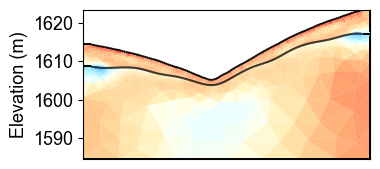

C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 5 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 6 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 7 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 8 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 9 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 11 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 12 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 13 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x600 with 14 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

In [4]:
from palettable.lightbartlein.diverging import BlueDarkRed18_18_r
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pylab as pylab
params = {'legend.fontsize': 13,
          #'figure.figsize': (15, 5),
         'axes.labelsize': 13,
         'axes.titlesize':13,
         'xtick.labelsize':13,
         'ytick.labelsize':13}

pylab.rcParams.update(params)
plt.rcParams["font.family"] = "Arial"

fixed_cmap = BlueDarkRed18_18_r.mpl_colormap
fig = plt.figure(figsize=[16, 6])

# Use tight_layout with adjusted parameters to reduce space
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# True resistivity model
for i in range(12):
    row, col = i // 4, i % 4
    ax = fig.add_subplot(3, 4, i+1)
    
    # Add common ylabel only to leftmost panels
    ylabel = "Elevation (m)" if col == 0 else None
    
    # Add resistivity label only to the middle-right panel (row 1, col 3)
    resistivity_label = ' Resistivity ($\Omega$ m)' if (i == 7) else None
    
    # Only show axis ticks on leftmost and bottom panels
    if col != 0:
        ax.set_yticks([])
    
    if row != 2:  # Not bottom row
        ax.set_xticks([])
    else:
        # Add "distance (m)" label to bottom row panels
        ax.set_xlabel("Distance (m)")
    
    # Create the plot
    ax, cbar = pg.show(mesh,
                      water_content_mean[:, i],
                      pad=0.3,
                      orientation="vertical",
                      cMap=fixed_cmap,
                      cMin=0,
                      cMax=0.32,
                      ylabel=ylabel,
                      label= 'Water Content (-)',
                      ax=ax,
                      logScale=False,
                      coverage=coverage[i,:]>-1.0)
    
    # Only keep colorbar for the middle-right panel (row 1, col 3)
    # This corresponds to panel index 7 in a 0-based indexing system
    if i != 7:  # Keep only the colorbar for panel 7
        cbar.remove()

plt.tight_layout()
plt.savefig("results/Structure_WC/timelapse_sat.tiff", dpi=300, bbox_inches='tight')

### Extract the true water content values

In [5]:
WC_true = []

for i in np.arange(30,361,30):
    # Extract true water content values for the current timestep
    true_values = np.load("results/TL_measurements/synwcmodel/synwcmodel"+str(i)+".npy")
      
    # Store the true values for this timestep
    WC_true.append(true_values)
mesh_true = pg.load("results/TL_measurements/mesh.bms")
WC_true = np.array(WC_true)
print(WC_true.shape)

(12, 11448)


### Pick up the comparison locations

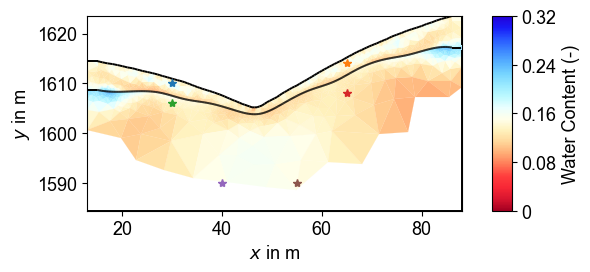

In [6]:
fig = plt.figure(figsize=[6, 3])
ax = fig.add_subplot(1, 1, 1)
ax, cbar = pg.show(mesh,
                water_content_mean[:, 4],
                pad=0.3,
                orientation="vertical",
                cMap=fixed_cmap,
                cMin=0,
                cMax=0.32,
                ylabel=ylabel,
                label= 'Water Content (-)',
                ax=ax,
                logScale=False,
                coverage=coverage[6,:]>-1.2)

ax.plot([30],[1610],'*')
ax.plot([65],[1614],'*')

ax.plot([30],[1606],'*')
ax.plot([65],[1608],'*')

ax.plot([40],[1590],'*')
ax.plot([55],[1590],'*')

### Function for analyze the time-series data

In [7]:
# Modified function to extract time series based on x AND y positions
def extract_mc_time_series(mesh, values_all, positions):
    """
    Extract Monte Carlo time series at specific x,y positions
    
    Args:
        mesh: PyGIMLI mesh
        values_all: Array of all Monte Carlo realizations (n_realizations, n_cells, n_timesteps)
        positions: List of (x,y) coordinate tuples
        
    Returns:
        time_series: Array of shape (n_positions, n_realizations, n_timesteps)
        cell_indices: List of cell indices corresponding to the positions
    """
    n_realizations = values_all.shape[0]
    n_timesteps = values_all.shape[2]
    
    # Find indices of cells closest to specified positions
    cell_indices = []
    for x_pos, y_pos in positions:
        # Calculate distance from each cell center to the position
        cell_centers = np.array(mesh.cellCenters())
        distances = np.sqrt((cell_centers[:, 0] - x_pos)**2 + (cell_centers[:, 1] - y_pos)**2)
        cell_idx = np.argmin(distances)
        cell_indices.append(cell_idx)
    
    # Extract time series for each realization and position
    time_series = np.zeros((len(positions), n_realizations, n_timesteps))
    
    for pos_idx, cell_idx in enumerate(cell_indices):
        for mc_idx in range(n_realizations):
            time_series[pos_idx, mc_idx, :] = values_all[mc_idx, cell_idx, :]
    
    return time_series, cell_indices


def extract_true_values_at_positions(mesh, true_values, positions):
    """
    Extract true water content values at specific x,y positions.
    
    Args:
        mesh: PyGIMLI mesh
        true_values: Array of true water content values (n_cells, n_timesteps) or (n_cells,)
        positions: List of (x,y) coordinate tuples
        
    Returns:
        true_values_at_positions: Values at each position
        cell_indices: List of cell indices corresponding to the positions
    """
    # Find indices of cells closest to specified positions
    cell_indices = []
    for x_pos, y_pos in positions:
        # Calculate distance from each cell center to the position
        cell_centers = np.array(mesh.cellCenters())
        distances = np.sqrt((cell_centers[:, 0] - x_pos)**2 + (cell_centers[:, 1] - y_pos)**2)
        cell_idx = np.argmin(distances)
        cell_indices.append(cell_idx)
    
    # Extract true values at the specified positions
    if true_values.ndim == 1:  # Single value per cell
        true_values_at_positions = true_values[cell_indices]
    elif true_values.ndim == 2:  # Time series per cell
        true_values_at_positions = true_values[cell_indices, :]
    else:
        raise ValueError("Unexpected shape for true_values")
    
    return true_values_at_positions, cell_indices



### Pick up the locations

In [8]:

# Define positions to sample (x,y coordinates)
positions = [
    (30, 1610),
    (65, 1613),  # Example coordinates, adjust based on your model
]

# Extract time series data for these positions
time_series_data, cell_indices = extract_mc_time_series(mesh, water_content_all, positions)
Pos1_true, _ = extract_true_values_at_positions(mesh_true, WC_true.T, positions)
Pos1_true

array([[0.11324638, 0.15233067, 0.15111991, 0.14376954, 0.16545146,
        0.14605083, 0.19172963, 0.20381934, 0.14155268, 0.14688543,
        0.12758784, 0.11908793],
       [0.11971362, 0.149832  , 0.13367899, 0.13735899, 0.14483882,
        0.13899105, 0.19341145, 0.17406773, 0.14533648, 0.14842166,
        0.13297472, 0.12541723]])

### Comparisons of water content

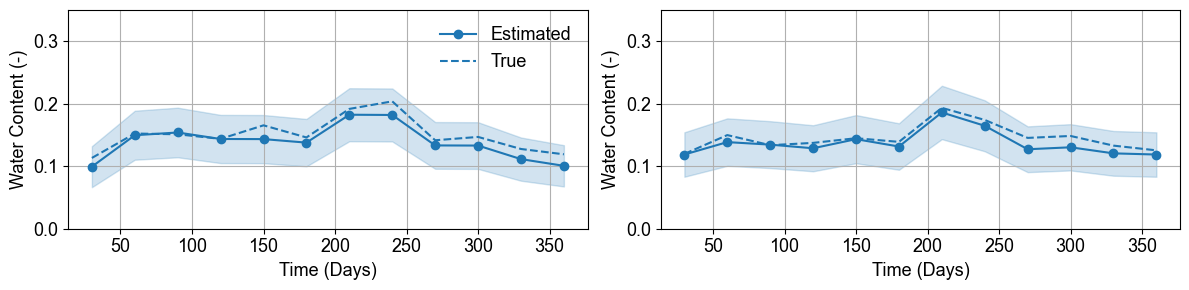

In [9]:
# Plot time series with uncertainty bands
plt.figure(figsize=(12, 3))

measurement_times = np.arange(30,361,30)  # Assuming sequential timesteps


# Calculate statistics
mean_ts = np.mean(time_series_data[0], axis=0)
std_ts = np.std(time_series_data[0], axis=0)

plt.subplot(1, 2, 1)
plt.plot(measurement_times, mean_ts, 'o-', color='tab:blue', label='Estimated')
plt.fill_between(measurement_times, mean_ts-std_ts, mean_ts+std_ts, color='tab:blue', alpha=0.2)
plt.plot(measurement_times,Pos1_true[0, :], 'tab:blue',ls='--', label='True')
plt.grid(True)
plt.legend(frameon=False)
plt.xlabel('Time (Days)')
plt.ylabel('Water Content (-)')
plt.ylim(0, 0.35)
plt.subplot(1, 2, 2)
mean_ts = np.mean(time_series_data[1], axis=0)
std_ts = np.std(time_series_data[1], axis=0)
plt.plot(measurement_times, mean_ts, 'o-', color='tab:blue',)
plt.fill_between(measurement_times, mean_ts-std_ts, mean_ts+std_ts, color='tab:blue', alpha=0.2)
plt.plot(measurement_times,Pos1_true[1, :], 'tab:blue',ls='--')
plt.xlabel('Time (Days)')
plt.ylabel('Water Content (-)')
plt.ylim(0, 0.35)
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/Structure_WC/regolith_WC.tiff", dpi=300, bbox_inches='tight')

## Fractured bedrock layer


In [10]:
### Fractured bedrock layer

# Define positions to sample (x,y coordinates)
positions = [
    (30, 1606),  # Example coordinates, adjust based on your model
    (65, 1608),
]

# Extract time series data for these positions
time_series_data2, cell_indices = extract_mc_time_series(mesh, water_content_all, positions)
Pos2_true, _ = extract_true_values_at_positions(mesh_true, WC_true.T, positions)
Pos2_true

array([[0.13761099, 0.13562016, 0.13872773, 0.14029772, 0.14405573,
        0.14904303, 0.17629743, 0.16088255, 0.16421667, 0.15322342,
        0.1488287 , 0.14348556],
       [0.13911318, 0.13543656, 0.13259384, 0.13040086, 0.13264936,
        0.13840835, 0.15002008, 0.1623058 , 0.16410032, 0.15118506,
        0.14593856, 0.14431303]])

## Plot time series with uncertainty bands


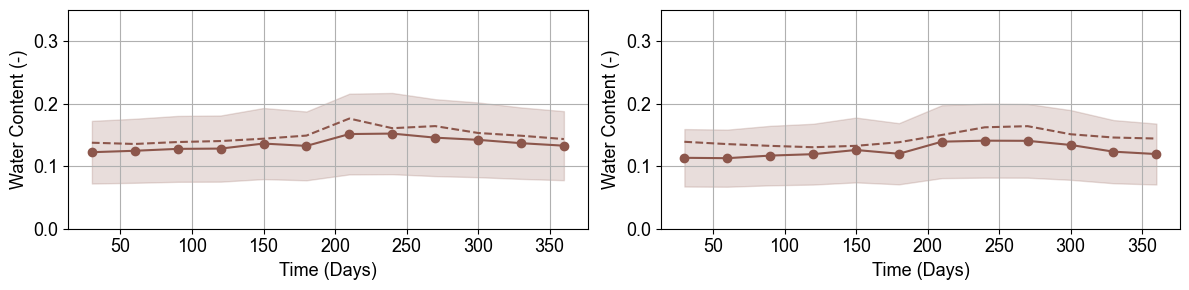

In [11]:
# Plot time series with uncertainty bands
plt.figure(figsize=(12, 3))

measurement_times = np.arange(30,361,30)  # Assuming sequential timesteps


# Calculate statistics
mean_ts = np.mean(time_series_data2[0], axis=0)
std_ts = np.std(time_series_data2[0], axis=0)

plt.subplot(1, 2, 1)
plt.plot(measurement_times, mean_ts, 'o-', color='tab:brown', label='Estimated')
plt.fill_between(measurement_times, mean_ts-std_ts, mean_ts+std_ts, color='tab:brown', alpha=0.2)
plt.plot(measurement_times,Pos2_true[0, :], 'tab:brown',ls='--', label='True')
plt.grid(True)
#plt.legend(frameon=False)
plt.xlabel('Time (Days)')
plt.ylabel('Water Content (-)')
plt.ylim(0, 0.35)
plt.subplot(1, 2, 2)
mean_ts = np.mean(time_series_data2[1], axis=0)
std_ts = np.std(time_series_data2[1], axis=0)
plt.plot(measurement_times, mean_ts, 'o-', color='tab:brown',)
plt.fill_between(measurement_times, mean_ts-std_ts, mean_ts+std_ts, color='tab:brown', alpha=0.2)
plt.plot(measurement_times,Pos2_true[1, :], 'tab:brown',ls='--')
plt.xlabel('Time (Days)')
plt.ylabel('Water Content (-)')
plt.ylim(0, 0.35)
# plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/Structure_WC/Fracture_WC.tiff", dpi=300, bbox_inches='tight')

### Estimate Porosity

In [12]:
# If we know the water table and then use it to estimate the porosity



# Import PyHydroGeophysX modules
from PyHydroGeophysX.petrophysics.resistivity_models import resistivity_to_porosity

# Extract the inverted resistivity values
resistivity_values = np.load("results/Structure_WC/resmodel.npy")
coverage = np.load("results/Structure_WC/all_coverage.npy")
# Extract cell markers from the mesh (to identify different geological layers)
cell_markers = np.load("results/Structure_WC/index_marker.npy")

mesh = pg.load("results/Structure_WC/mesh_res.bms")

# Number of Monte Carlo realizations
n_realizations = 100

# Assume full saturation under the water table
saturation_value = 1.0

# Set up parameter distributions (means and standard deviations)
# For porosity estimation from resistivity with known saturation

# Layer 1 (top layer - marker 3) - Regolith/Soil
layer1_dist = {
    'm': {'mean': 1.3, 'std': 0.1},               # Cementation exponent (lower for unconsolidated)
    'n': {'mean': 2.1, 'std': 0.1},               # Saturation exponent
    'sigma_sur': {'mean': 1/200, 'std': 1/200},  # Surface conductivity (S/m)
}

# Layer 2 (bottom layer - marker 2) - Fractured/Fresh Bedrock
layer2_dist = {
    'm': {'mean': 1.9, 'std': 0.2},               # Cementation exponent (higher for consolidated)
    'n': {'mean': 1.7, 'std': 0.2},               # Saturation exponent
    'sigma_sur': {'mean': 0.0, 'std': 0.0},      # No surface conductivity in bedrock
}

# Create arrays to store all MC realization results
porosity_all = np.zeros((n_realizations, *resistivity_values.shape))
water_content_all = np.zeros((n_realizations, *resistivity_values.shape))  # Since saturation = 1, WC = porosity

# Create arrays to store the parameters used for each realization
params_used = {
    'layer1': {
        'm': np.zeros(n_realizations),
        'rho_fluid': np.zeros(n_realizations),
        'n': np.zeros(n_realizations),
        'sigma_sur': np.zeros(n_realizations),
    },
    'layer2': {
        'm': np.zeros(n_realizations),
        'rho_fluid': np.zeros(n_realizations),
        'n': np.zeros(n_realizations),
        'sigma_sur': np.zeros(n_realizations),
    }
}

# Perform Monte Carlo simulation
print("Starting Monte Carlo simulation for porosity estimation...")
print(f"Assuming full saturation (S = {saturation_value}) everywhere")

for mc_idx in tqdm(range(n_realizations), desc="MC Realizations"):
    
    # Sample parameters for each layer from their distributions
    # Layer 1 (Top layer - Regolith/Soil)
    layer1_params = {
        'm': max(0.0, np.random.normal(layer1_dist['m']['mean'], layer1_dist['m']['std'])),
        'rho_fluid': 20,
        'n': max(0.0, np.random.normal(layer1_dist['n']['mean'], layer1_dist['n']['std'])),
        'sigma_sur': max(0.0, np.random.normal(layer1_dist['sigma_sur']['mean'], layer1_dist['sigma_sur']['std'])),
    }
    
    # Layer 2 (Bottom layer - Bedrock)
    layer2_params = {
        'm': max(0.0, np.random.normal(layer2_dist['m']['mean'], layer2_dist['m']['std'])),
        'rho_fluid': 20,
        'n': max(0.0, np.random.normal(layer2_dist['n']['mean'], layer2_dist['n']['std'])),
        'sigma_sur': 0,
    }
    
    # Save the parameters used for this realization
    params_used['layer1']['m'][mc_idx] = layer1_params['m']
    params_used['layer1']['rho_fluid'][mc_idx] = layer1_params['rho_fluid']
    params_used['layer1']['n'][mc_idx] = layer1_params['n']
    params_used['layer1']['sigma_sur'][mc_idx] = layer1_params['sigma_sur']
    
    params_used['layer2']['m'][mc_idx] = layer2_params['m']
    params_used['layer2']['rho_fluid'][mc_idx] = layer2_params['rho_fluid']
    params_used['layer2']['n'][mc_idx] = layer2_params['n']
    params_used['layer2']['sigma_sur'][mc_idx] = layer2_params['sigma_sur']
    
    # Create arrays to store porosity for this realization
    porosity = np.zeros_like(resistivity_values)
    
    # Process each timestep
    for t in range(resistivity_values.shape[1]):
        # Extract resistivity for this timestep
        resistivity_t = resistivity_values[:, t]
        
        # Process each layer separately using resistivity_to_porosity function
        
        # Layer 1 (marker 3) - Top layer
        mask_layer1 = cell_markers == 3
        if np.any(mask_layer1):
            porosity[mask_layer1, t] = resistivity_to_porosity(
                resistivity=resistivity_t[mask_layer1],
                saturation=saturation_value,  # Full saturation
                m=layer1_params['m'],
                rho_fluid=layer1_params['rho_fluid'],
                n=layer1_params['n'],
                sigma_sur=layer1_params['sigma_sur'],
                a=1.0  # Fixed tortuosity
            )
        
        # Layer 2 (marker 2) - Bottom layer
        mask_layer2 = cell_markers == 2
        if np.any(mask_layer2):
            porosity[mask_layer2, t] = resistivity_to_porosity(
                resistivity=resistivity_t[mask_layer2],
                saturation=saturation_value,  # Full saturation
                m=layer2_params['m'],
                rho_fluid=layer2_params['rho_fluid'],
                n=layer2_params['n'],
                sigma_sur=layer2_params['sigma_sur'],
                a=1.0 # Fixed tortuosity for bedrock
            )
    
    # Store this realization's porosity
    porosity_all[mc_idx] = porosity
    
    # Since saturation = 1, water content = porosity
    water_content_all[mc_idx] = porosity

print("Monte Carlo simulation completed!")

# Calculate statistics across all realizations
print("Calculating statistics...")
porosity_mean = np.mean(porosity_all, axis=0)
porosity_std = np.std(porosity_all, axis=0)




Starting Monte Carlo simulation for porosity estimation...
Assuming full saturation (S = 1.0) everywhere


MC Realizations:   0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\petrophysics\resistivity_models.py:338: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  solution = fsolve(func, initial_guess)
C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\petrophysics\resistivity_models.py:338: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  solution = fsolve(func, initial_guess)


MC Realizations:   1%|          | 1/100 [00:01<02:10,  1.32s/it]

MC Realizations:   2%|▏         | 2/100 [00:02<01:52,  1.15s/it]

...

MC Realizations:  96%|█████████▌| 96/100 [01:13<00:02,  1.47it/s]

MC Realizations:  97%|█████████▋| 97/100 [01:14<00:02,  1.39it/s]

MC Realizations:  98%|█████████▊| 98/100 [01:15<00:01,  1.26it/s]

MC Realizations: 100%|██████████| 100/100 [01:15<00:00,  1.32it/s]

Monte Carlo simulation completed!
Calculating statistics...


### Unsaturated zone comparison

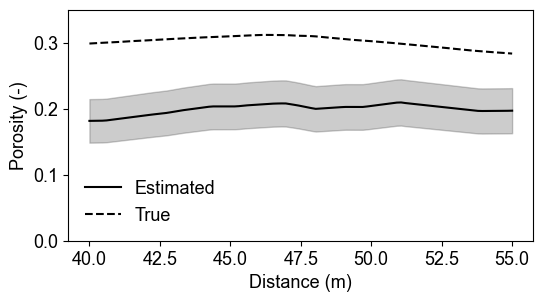

In [13]:
from scipy.interpolate import griddata

porosity_true = pg.load("results/TL_measurements/porosity.npy")
mesh_centers = np.array(mesh_true.cellCenters())
x1, y1 = np.mgrid[40:55:100j, 1600:1600:1j]
po_1 = griddata(mesh_centers[:,0:2], porosity_true, (x1, y1), method='linear')

mesh_centers2 = np.array(mesh.cellCenters())
po_2 = griddata(mesh_centers2[:,0:2], porosity_mean[:,10], (x1, y1), method='linear')
std_2 = griddata(mesh_centers2[:,0:2], porosity_std[:,10], (x1, y1), method='linear')

fig = plt.figure(figsize=[6, 3])

plt.plot(x1,po_2,c='k',label='Estimated')
plt.fill_between(x1.ravel(),po_2.ravel()-std_2.ravel(), po_2.ravel()+std_2.ravel(), color='k', alpha=0.2)
plt.plot(x1,po_1,c='k',ls='--',label='True')
plt.ylim(0, 0.35)
plt.xlabel('Distance (m)')
plt.ylabel('Porosity (-)')
plt.legend(frameon=False)

### Saturated zone comparison

(0.0, 0.35)

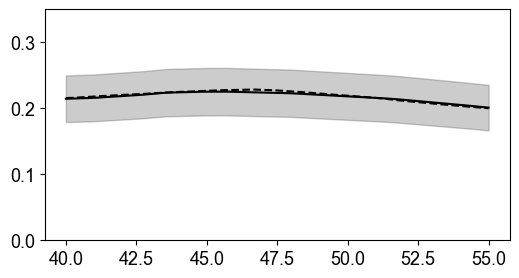

In [14]:
from scipy.interpolate import griddata

porosity_true = pg.load("results/TL_measurements/porosity.npy")
mesh_centers = np.array(mesh_true.cellCenters())
x1, y1 = np.mgrid[40:55:100j, 1590:1590:1j]
po_1 = griddata(mesh_centers[:,0:2], porosity_true, (x1, y1), method='linear')

mesh_centers2 = np.array(mesh.cellCenters())
po_2 = griddata(mesh_centers2[:,0:2], porosity_mean[:,10], (x1, y1), method='linear')
std_2 = griddata(mesh_centers2[:,0:2], porosity_std[:,10], (x1, y1), method='linear')

fig = plt.figure(figsize=[6, 3])
plt.plot(x1,po_1,c='k',ls='--',label='True')
plt.plot(x1,po_2, c='k',label='Estimated')
plt.fill_between(x1.ravel(),po_2.ravel()-std_2.ravel(), po_2.ravel()+std_2.ravel(), color='k', alpha=0.2)
plt.ylim(0, 0.35)